# Finding guided portion of field via contour integration

Here we see if this is possible using the basic guide as a test case.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from slab import SlabExact, plot_complex
from scipy.integrate import quad
from scipy.optimize import newton
%matplotlib widget
plt.style.use('dark_background')

In [2]:
A = SlabExact(symmetric=True, Ts=[3,2,3])

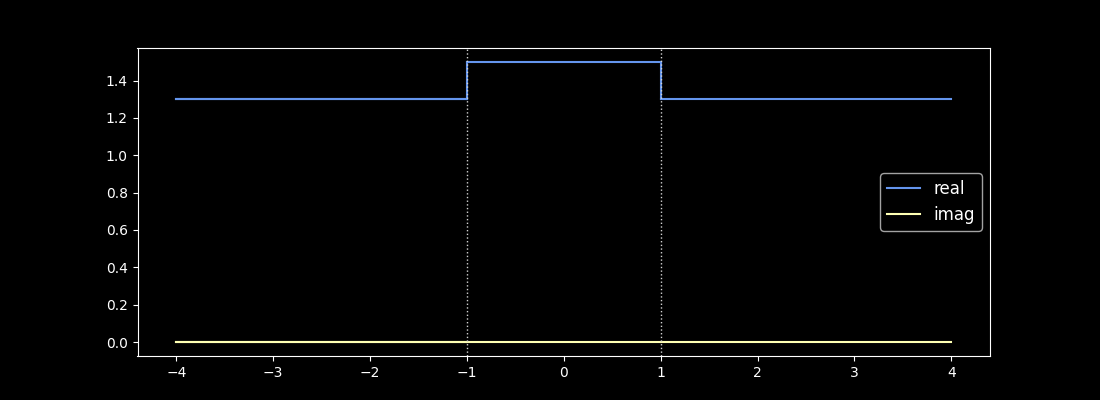

In [3]:
A.plot_refractive_index();

## Input fields

In [4]:
w = .5
s = -.15
amp = 2.5

Lx = -w + s
Rx = w + s

def quadratic_piecewise(x):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    return np.piecewise(x, conds, funcs)

def quadratic_piecewise2d(x, zs=None, wavenumber=A.K0):
    conds = [(x<Lx), ((Lx<=x)*(x<=Rx)), (x>Rx)]
    funcs = [0, lambda x: amp * (1 - ((x-s)/w)**2), 0]
    fx = np.piecewise(x, conds, funcs)
    fz = np.exp(1j * wavenumber * zs)
    return np.outer(fz, fx)

f0 = quadratic_piecewise

In [5]:
xs = np.linspace(-5,5,2000)

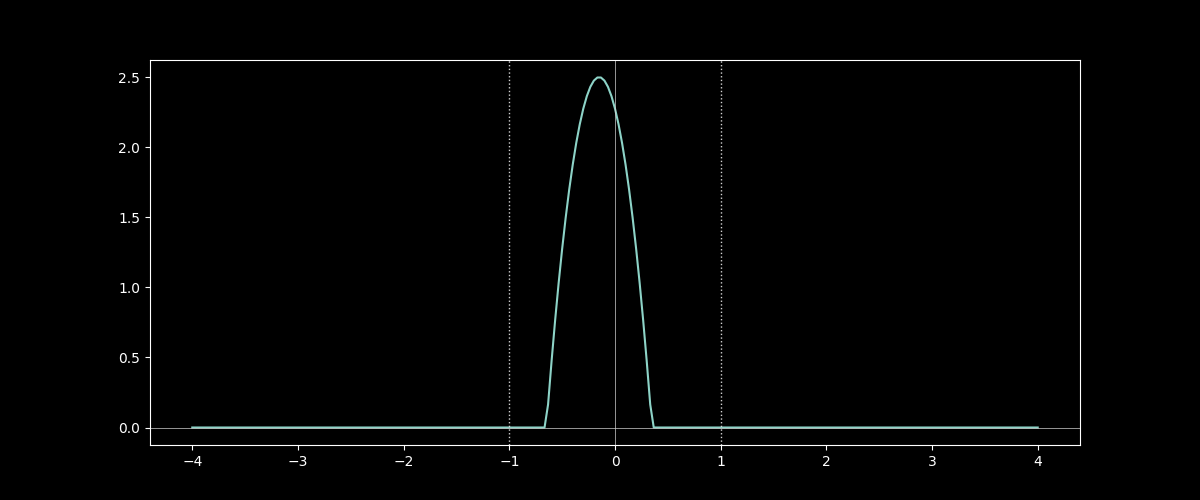

In [6]:
A.plot_field_1d(f0);

In [16]:
# A.plot_field_2d(quadratic_piecewise2d, xs=xs, zmin=-10, zmax=0, zref=100)

## Guided field via modefinding

We go ahead and find the true field first.

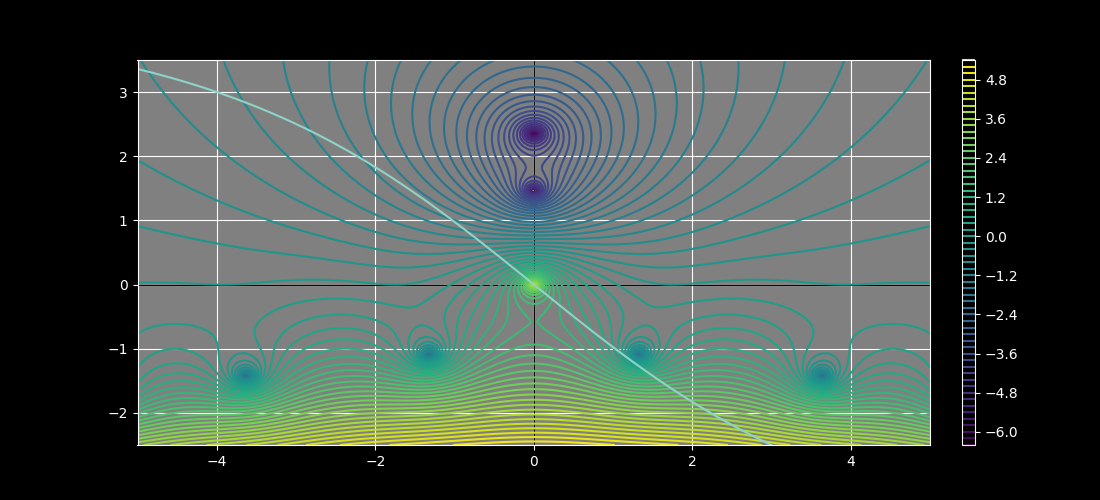

In [7]:
A.determinant_plot(-5, 5, -2.5, 3.5);

In [8]:
guesses = [2.5j, 1.48j]
Zs = np.array([newton(A.determinant, np.array(guess)) for guess in guesses])
A.plot_points(Zs)

In [9]:
Fs = [A.fields(Z, mode_type='guided') for Z in Zs]
coeffs = np.array([quad(lambda x: f0(x) * F(x)[0], -1, 1, complex_func=True)[0] for F in Fs])
coeffs

array([1.33361461+0.00000000e+00j, 0.36370963+1.45988955e-18j])

In [10]:
x0 = 0
z0 = 0
guided_x = lambda x: sum([alpha * F(x, z0)[0] for (alpha, F) in zip(coeffs, Fs)])
guided_z = lambda z: sum([alpha * F(x0, z)[:,0] for (alpha, F) in zip(coeffs, Fs)])
Guided = lambda x, z: sum([alpha * F(x, z) for (alpha, F) in zip(coeffs, Fs)])

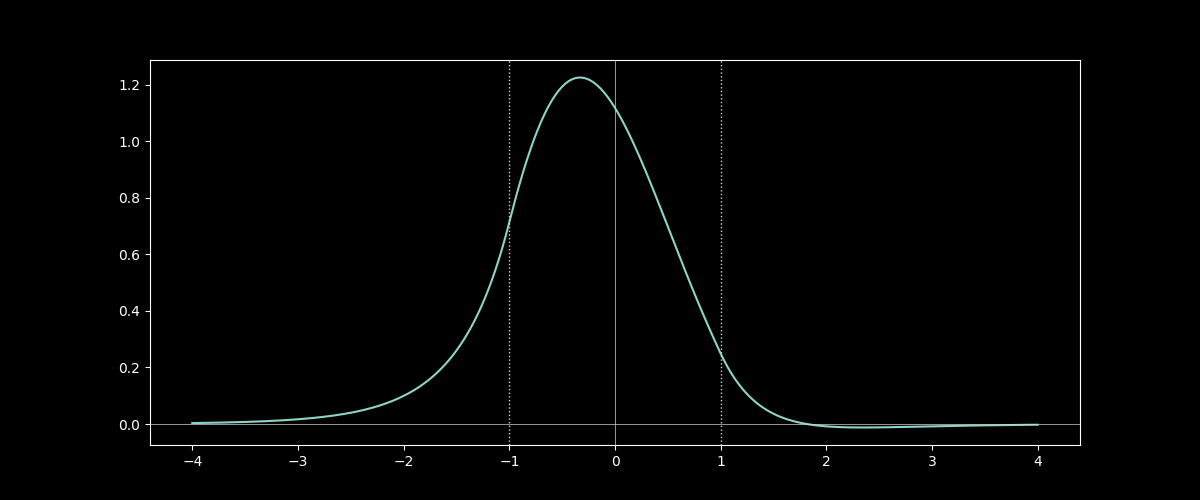

In [11]:
A.plot_field_1d(guided_x);

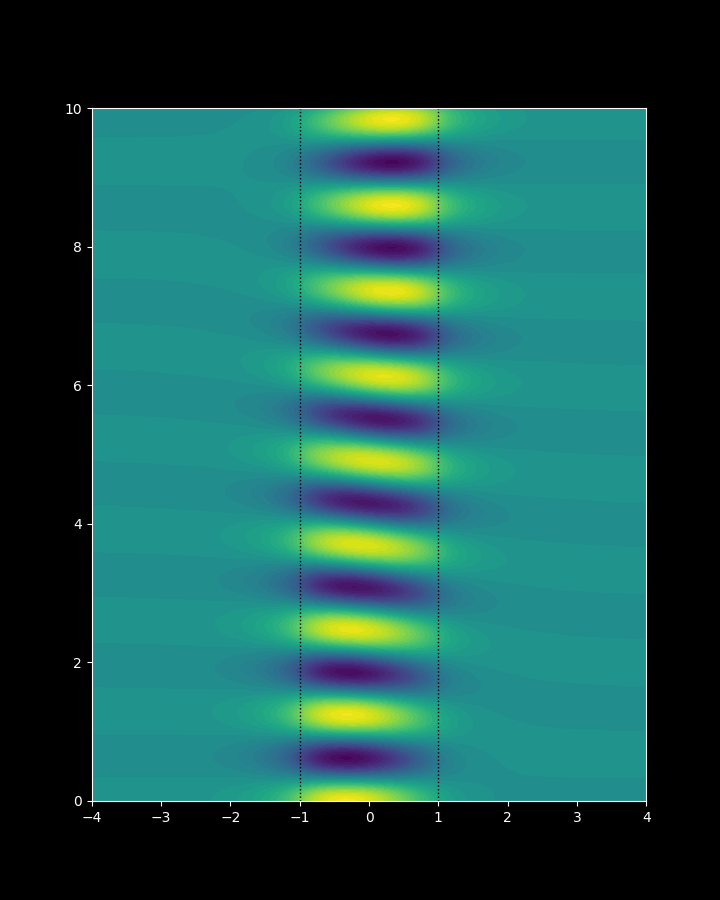

In [12]:
A.plot_field_2d(Guided, zs=np.linspace(0, 10, 200), colorbar=False);

## Guided field via integration


In [222]:
Propagator = A.propagator()
Normalizer = A.normalizer('eigvec')

We should integrate from 0 to iV.

Quick check to see that it seems guided modes are limited by these bounds in the Z plane:

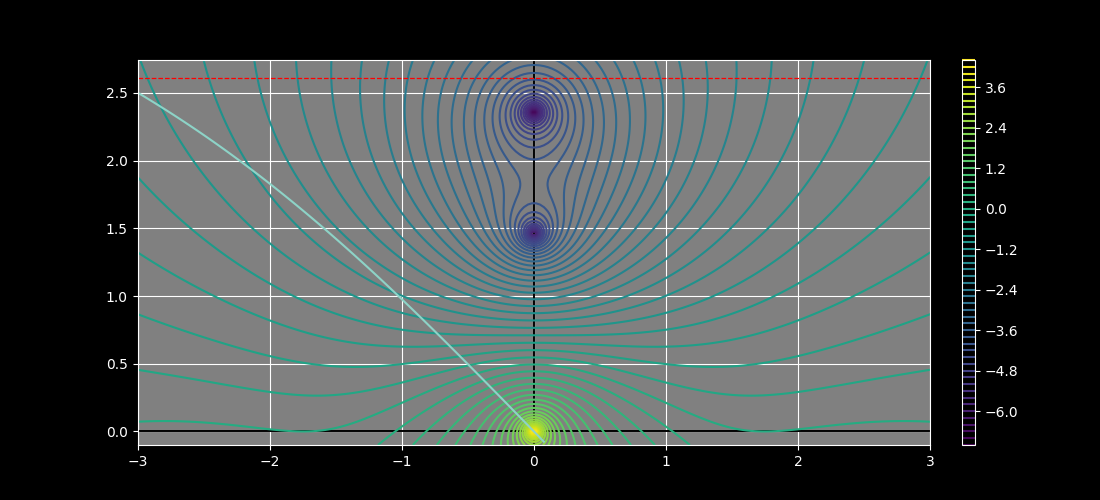

In [223]:
A.determinant_plot(-3, 3, -.1, 1.05*A.V.real, axis_linewidth=1.4)
plt.axhline(A.V.real, color='r', lw=.9, ls='--');

We will offset the integration slightly, because we know the radiation modes along the imaginary axis in the Z plane are badly behaved.

In [289]:
x_intercept = .001

top = A.horizontal_contour(A.V, 1e-10, x_intercept, 120) 
vertical = A.vertical_contour(x_intercept, A.V, 0, 500)
bottom = A.real_contour(x_intercept, 1e-6, 120)

ax = plt.gca()
for contour in [top, vertical, bottom]:
    ax.plot(contour['Cs'].real, contour['Cs'].imag, lw=1);

In [290]:
Ptop_e = Propagator(top, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer)
Ptop_o = Propagator(top, f0=f0, Lx=Lx, Rx=Rx, sign=-1, Normalizer=Normalizer)

Pvert_e = Propagator(vertical, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer)
Pvert_o = Propagator(vertical, f0=f0, Lx=Lx, Rx=Rx, sign=-1, Normalizer=Normalizer)

Pbot_e = Propagator(bottom, f0=f0, Lx=Lx, Rx=Rx, Normalizer=Normalizer)
Pbot_o = Propagator(bottom, f0=f0, Lx=Lx, Rx=Rx, sign=-1, Normalizer=Normalizer)


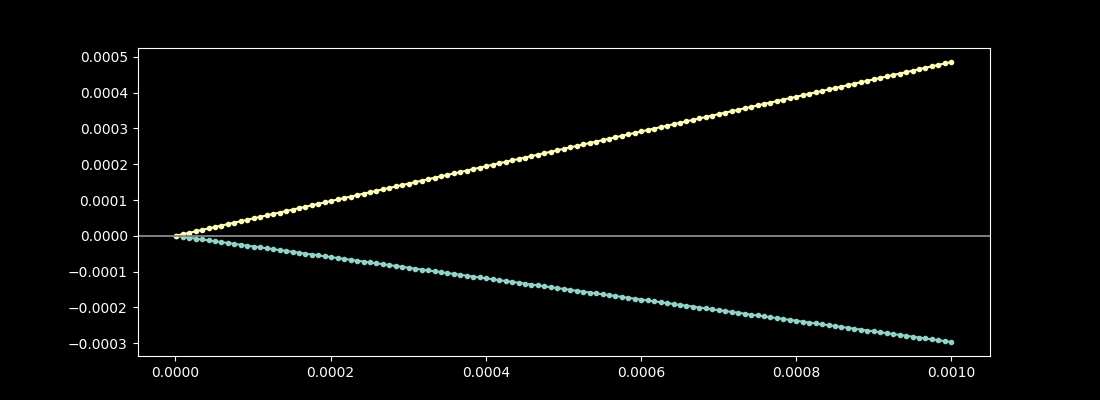

In [291]:
Pbot_e.plot_transform()
Pbot_o.plot_transform(ax=plt.gca());

In [294]:
Ps = [
    Ptop_e, Ptop_o,
    Pvert_e, Pvert_o,
    # Pbot_e, Pbot_o,
]

In [295]:
Pbot_o.propagate(.01, 0)

array([[-4.8182631e-11+0.j]])

In [296]:
int_guided_x = lambda x: sum([P.slice_propagate(x, slice_at=z0, constant_variable='z') for P in Ps]) 
int_guided_z = lambda z: sum([P.slice_propagate(z, slice_at=x0, constant_variable='x') for P in Ps])

Int_Guided = lambda x, z: sum([P.propagate(x, zs=z) for P in Ps])

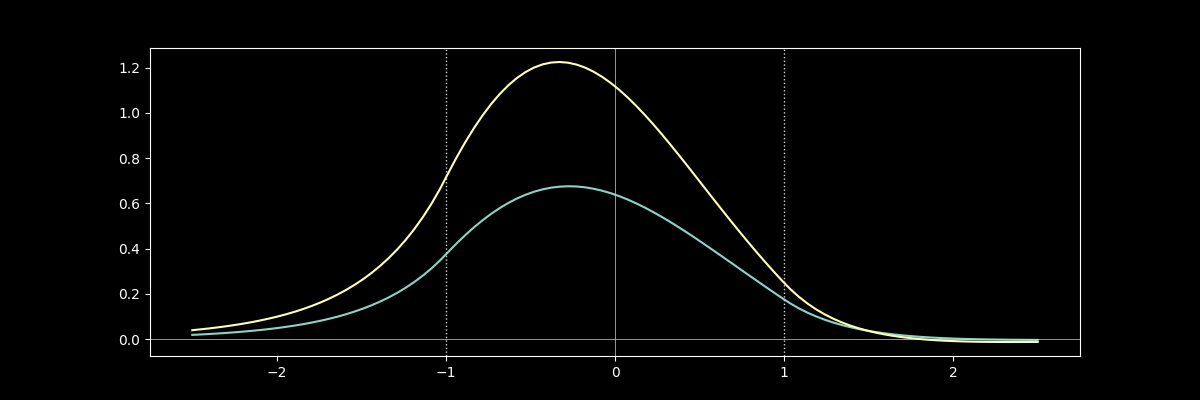

In [298]:
W = 2.5
xs2 = np.linspace(-W, W, 100)
A.plot_field_1d(int_guided_x, figsize=(12,4), xs=xs2, part='real')
A.add_1d_plot(guided_x, xs=xs2)

(<Figure size 1200x400 with 1 Axes>, <Axes: >)

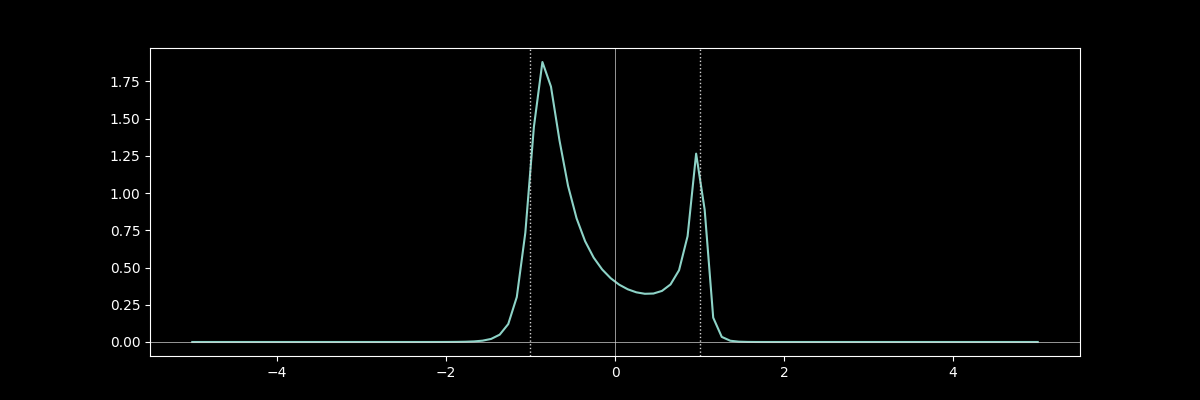

In [272]:
A.plot_field_1d(lambda x: guided_x(x) / int_guided_x(x), figsize=(12,4), xs=2*xs2, part='real')

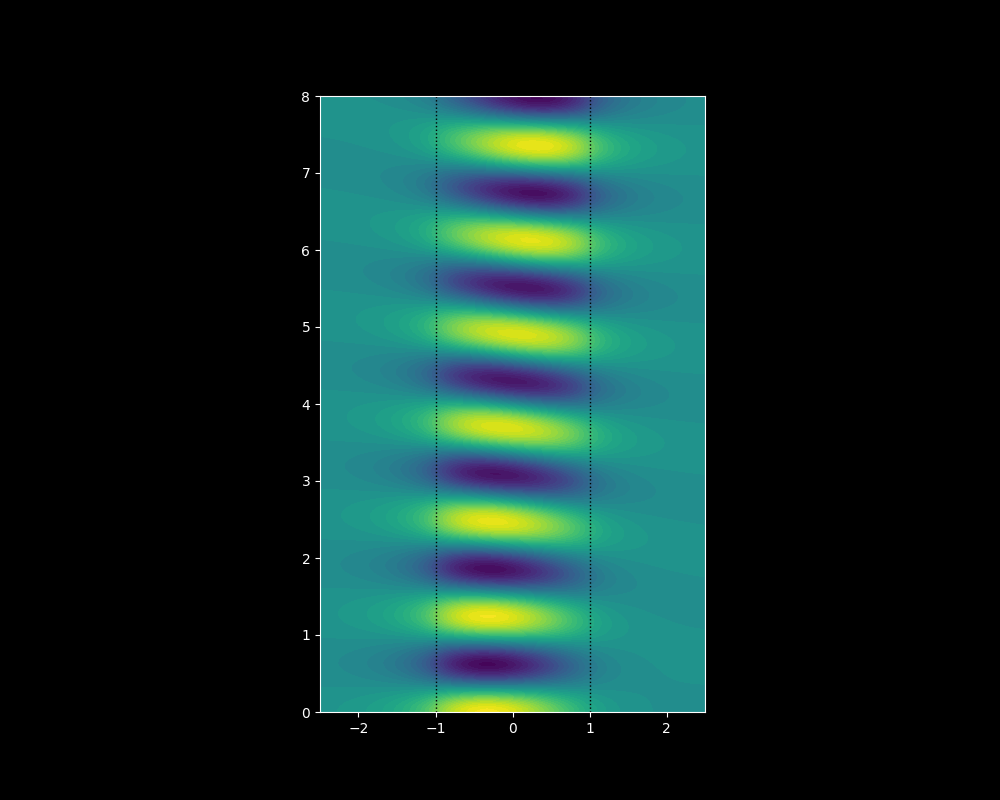

In [187]:
A.plot_field_2d(Guided, xs=xs2, colorbar=False, figsize=(10,8),
                zmax=8, zref=200);

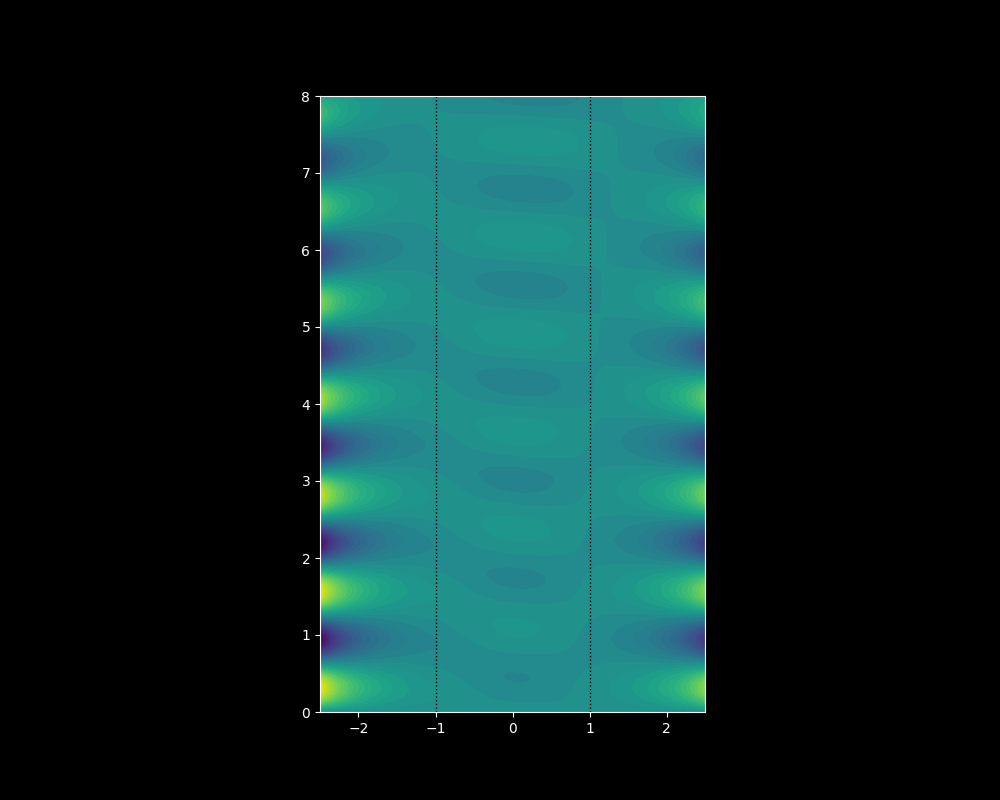

In [188]:
A.plot_field_2d(Int_Guided, xs=xs2, colorbar=False, figsize=(10,8),
                zmax=8, zref=200);

# Adding other pieces of path

We are deforming away from the imaginary axis, so we need to add in the other edges of the box, to get the correct integral.

# Observations

There may be something here, but not clear yet.

- It does seem that the field obtained by integration near the imaginary axis from 0 to iV has a similar form to the guided field, but also doesn't seem to converge to it as we move contour towards imaginary axis.